<a href="https://colab.research.google.com/github/ArshanBhanage/258-Assignment_3/blob/main/colab_b_pytorch_scratch_3layer_no_builtin_layers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colab (b) — PyTorch “from scratch” 3-Layer Deep Neural Network (Nonlinear Regression)
**Goal:** Implement a **3-layer** neural network for **nonlinear regression** using PyTorch **WITHOUT using built-in layer modules** like `nn.Linear`, `nn.Sequential`, etc.

✅ Requirements covered:
- Synthetic data from a **3-variable nonlinear equation** `(x1, x2, x3) -> y`
- **3-layer** network: `3 → H1 → H2 → 1`
- Proper **nonlinear activations**
- Training loop with loss vs epochs + final outputs
- “4D plot”: PCA to 3D + color = y

🚫 What we do **NOT** use:
- `torch.nn.Linear`, `torch.nn.Sequential`, `torch.nn.Module` (that’s part (c))
- Any pre-built layer functionality

✅ What we DO use (allowed):
- `torch.Tensor` math
- Autograd (`loss.backward()`) for gradients
- Manual SGD updates with `torch.no_grad()`


## 0. Setup

In [1]:
# !pip -q install torch numpy matplotlib scikit-learn

import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch:", torch.__version__)
print("Device:", device)


Torch: 2.10.0+cpu
Device: cpu


## 1. Generate synthetic nonlinear regression data (3 variables)

In [2]:
def nonlinear_equation(x1, x2, x3):
    return (
        2.0 * np.sin(x1)
        + 0.5 * (x2 ** 2)
        - 3.0 * np.exp(-x3)
        + 0.3 * x1 * x2
        - 0.2 * x2 * x3
    )

N = 6000
x1 = np.random.uniform(-3.0, 3.0, size=(N, 1))
x2 = np.random.uniform(-2.0, 2.0, size=(N, 1))
x3 = np.random.uniform(0.0, 4.0, size=(N, 1))

X = np.concatenate([x1, x2, x3], axis=1)  # (N,3)
noise = np.random.normal(0.0, 0.2, size=(N, 1))
y = nonlinear_equation(x1, x2, x3).reshape(-1, 1) + noise  # (N,1)

print("X shape:", X.shape, "y shape:", y.shape)


X shape: (6000, 3) y shape: (6000, 1)


## 2. Quick visualization ("4D" plot via PCA + color = y)

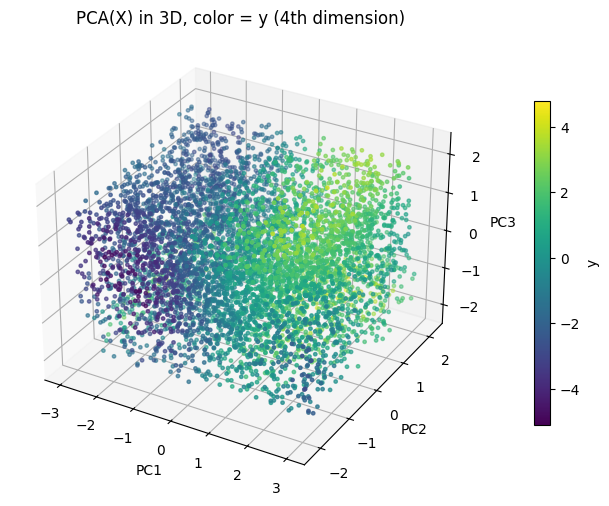

In [3]:
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=y[:, 0], s=6)
ax.set_title("PCA(X) in 3D, color = y (4th dimension)")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
plt.colorbar(sc, ax=ax, pad=0.1, shrink=0.7, label="y")
plt.show()


## 3. Train/Val/Test split + standardization

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

x_scaler = StandardScaler()
X_train_s = x_scaler.fit_transform(X_train)
X_val_s   = x_scaler.transform(X_val)
X_test_s  = x_scaler.transform(X_test)

y_scaler = StandardScaler()
y_train_s = y_scaler.fit_transform(y_train)
y_val_s   = y_scaler.transform(y_val)
y_test_s  = y_scaler.transform(y_test)

print("Train:", X_train_s.shape, y_train_s.shape)
print("Val  :", X_val_s.shape, y_val_s.shape)
print("Test :", X_test_s.shape, y_test_s.shape)


Train: (4200, 3) (4200, 1)
Val  : (900, 3) (900, 1)
Test : (900, 3) (900, 1)


## 4. Build a 3-layer network using only raw tensors (no nn.Linear)

In [5]:
# Hyperparameters / architecture
d_in = 3
h1 = 64
h2 = 32
d_out = 1

lr = 1e-3
epochs = 250
batch_size = 128

# Xavier-like init helper
def xavier_init(in_dim, out_dim):
    limit = np.sqrt(6.0 / (in_dim + out_dim))
    w = np.random.uniform(-limit, limit, size=(in_dim, out_dim)).astype(np.float32)
    return torch.tensor(w, device=device, requires_grad=True)

# Parameters (trainable)
W1 = xavier_init(d_in, h1)
b1 = torch.zeros(h1, device=device, requires_grad=True)

W2 = xavier_init(h1, h2)
b2 = torch.zeros(h2, device=device, requires_grad=True)

W3 = xavier_init(h2, d_out)
b3 = torch.zeros(d_out, device=device, requires_grad=True)

params = [W1, b1, W2, b2, W3, b3]

def forward(Xb):
    # Layer 1
    z1 = Xb @ W1 + b1
    a1 = torch.tanh(z1)

    # Layer 2
    z2 = a1 @ W2 + b2
    a2 = torch.tanh(z2)

    # Layer 3 (linear output)
    yhat = a2 @ W3 + b3
    return yhat

def mse_loss(y_true, y_pred):
    return torch.mean((y_pred - y_true) ** 2)

print("Parameter shapes:")
print("W1", tuple(W1.shape), "b1", tuple(b1.shape))
print("W2", tuple(W2.shape), "b2", tuple(b2.shape))
print("W3", tuple(W3.shape), "b3", tuple(b3.shape))


Parameter shapes:
W1 (3, 64) b1 (64,)
W2 (64, 32) b2 (32,)
W3 (32, 1) b3 (1,)


## 5. Mini-batch training loop (autograd + manual SGD update)

Epoch    1 | train MSE: 1.129802 | val MSE: 1.010891
Epoch   25 | train MSE: 0.410840 | val MSE: 0.449742
Epoch   50 | train MSE: 0.404438 | val MSE: 0.442960
Epoch   75 | train MSE: 0.395769 | val MSE: 0.434876
Epoch  100 | train MSE: 0.386119 | val MSE: 0.424146
Epoch  125 | train MSE: 0.372719 | val MSE: 0.410157
Epoch  150 | train MSE: 0.354129 | val MSE: 0.391038
Epoch  175 | train MSE: 0.328875 | val MSE: 0.365096
Epoch  200 | train MSE: 0.297290 | val MSE: 0.331893
Epoch  225 | train MSE: 0.259238 | val MSE: 0.292574
Epoch  250 | train MSE: 0.219703 | val MSE: 0.251083


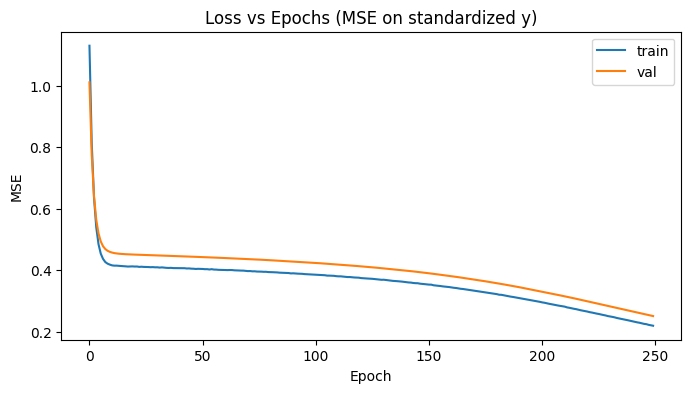

In [6]:
# Convert data to torch tensors
X_train_t = torch.tensor(X_train_s, dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train_s, dtype=torch.float32, device=device)

X_val_t = torch.tensor(X_val_s, dtype=torch.float32, device=device)
y_val_t = torch.tensor(y_val_s, dtype=torch.float32, device=device)

def iterate_minibatches_torch(Xt, yt, batch_size=128, shuffle=True):
    n = Xt.shape[0]
    idx = torch.randperm(n, device=device) if shuffle else torch.arange(n, device=device)
    for start in range(0, n, batch_size):
        batch_idx = idx[start:start+batch_size]
        yield Xt[batch_idx], yt[batch_idx]

train_losses, val_losses = [], []

for epoch in range(1, epochs + 1):
    # ---- Train ----
    W1.train if hasattr(W1, "train") else None  # no-op; kept for symmetry with later parts
    epoch_train_loss = 0.0
    steps = 0

    for Xb, yb in iterate_minibatches_torch(X_train_t, y_train_t, batch_size=batch_size, shuffle=True):
        # Forward
        yhat = forward(Xb)
        loss = mse_loss(yb, yhat)

        # Backward
        loss.backward()

        # Manual SGD step (NO torch.optim used)
        with torch.no_grad():
            for p in params:
                p -= lr * p.grad

        # Zero gradients
        for p in params:
            p.grad = None

        epoch_train_loss += float(loss.detach().cpu().item())
        steps += 1

    epoch_train_loss /= max(steps, 1)

    # ---- Validate ----
    with torch.no_grad():
        yval_hat = forward(X_val_t)
        val_loss = float(mse_loss(y_val_t, yval_hat).detach().cpu().item())

    train_losses.append(epoch_train_loss)
    val_losses.append(val_loss)

    if epoch % 25 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d} | train MSE: {epoch_train_loss:.6f} | val MSE: {val_loss:.6f}")

# Plot loss curves
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.title("Loss vs Epochs (MSE on standardized y)")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()


## 6. Final evaluation on test set + true vs predicted plot

Final TEST MSE (original y scale): 0.800012995346129


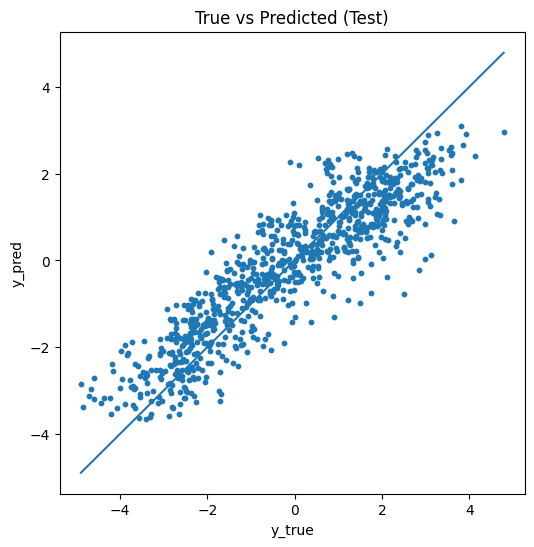

Example 0: y_true= 0.509 | y_pred= 0.144
Example 1: y_true=-2.526 | y_pred=-2.320
Example 2: y_true= 1.109 | y_pred= 0.649
Example 3: y_true=-0.009 | y_pred= 0.598
Example 4: y_true=-3.119 | y_pred=-3.286
Example 5: y_true=-2.076 | y_pred=-1.457
Example 6: y_true= 2.823 | y_pred= 1.964
Example 7: y_true=-2.021 | y_pred=-0.260
Example 8: y_true= 2.596 | y_pred= 0.836
Example 9: y_true=-1.838 | y_pred=-1.244


In [7]:
X_test_t = torch.tensor(X_test_s, dtype=torch.float32, device=device)
y_test_t = torch.tensor(y_test_s, dtype=torch.float32, device=device)

with torch.no_grad():
    y_test_hat_s = forward(X_test_t).detach().cpu().numpy()

# Inverse transform to original y scale
y_test_hat = y_scaler.inverse_transform(y_test_hat_s)
y_test_true = y_test

test_mse = float(np.mean((y_test_hat - y_test_true) ** 2))
print("Final TEST MSE (original y scale):", test_mse)

plt.figure(figsize=(6, 6))
plt.scatter(y_test_true[:, 0], y_test_hat[:, 0], s=10)
plt.title("True vs Predicted (Test)")
plt.xlabel("y_true")
plt.ylabel("y_pred")
minv = min(y_test_true.min(), y_test_hat.min())
maxv = max(y_test_true.max(), y_test_hat.max())
plt.plot([minv, maxv], [minv, maxv])
plt.show()

for i in range(10):
    print(f"Example {i}: y_true={y_test_true[i,0]: .3f} | y_pred={y_test_hat[i,0]: .3f}")


## 7. Save learned weights (optional)

In [8]:
save_path = "pytorch_scratch_3layer_weights.pt"
state = {
    "W1": W1.detach().cpu(),
    "b1": b1.detach().cpu(),
    "W2": W2.detach().cpu(),
    "b2": b2.detach().cpu(),
    "W3": W3.detach().cpu(),
    "b3": b3.detach().cpu(),
    "x_mean": torch.tensor(x_scaler.mean_),
    "x_scale": torch.tensor(x_scaler.scale_),
    "y_mean": torch.tensor(y_scaler.mean_),
    "y_scale": torch.tensor(y_scaler.scale_),
}
torch.save(state, save_path)
print("Saved:", save_path)


Saved: pytorch_scratch_3layer_weights.pt
